In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [ ]:

print(df.isnull().sum())  # Optional: see which columns have NaNs

# Drop rows with any NaNs
df = df.dropna()
# Fill missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)


diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [10]:
# Check how many rows are left after dropping NaNs
print(df.shape)

# If you still have enough rows, proceed with the split


(0, 32)


In [11]:
# Check missing values per column
print(df.isnull().sum())


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
Unnamed: 32                0
dtype: int64


In [12]:
# Remove the unwanted column
df = df.drop(columns=['Unnamed: 32'])


In [14]:
# Check if the data is now clean
print(df.shape)


(0, 31)


Confusion Matrix:
[[70  1]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


ROC-AUC: 0.99737962659679


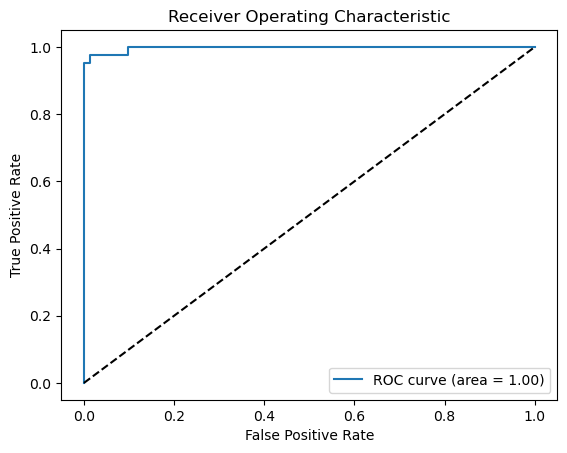

In [16]:
# Load dataset
df = pd.read_csv('data.csv')

# Remove the unnecessary 'Unnamed: 32' column
df = df.drop(columns=['Unnamed: 32'])

# Encode diagnosis (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop ID column if present
df.drop(['id'], axis=1, inplace=True)

# Split into X and y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print("\nROC-AUC:", roc_auc)

# Plot ROC Curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


In [17]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# Function to calculate metrics for a given threshold
def evaluate_threshold(threshold, y_test, y_pred_proba):
    y_pred = (y_pred_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

# Model probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.linspace(0, 1, 11)
for t in thresholds:
    evaluate_threshold(t, y_test, y_pred_proba)


Threshold: 0.00 | Precision: 0.3772 | Recall: 1.0000
Threshold: 0.10 | Precision: 0.8571 | Recall: 0.9767
Threshold: 0.20 | Precision: 0.9130 | Recall: 0.9767
Threshold: 0.30 | Precision: 0.9130 | Recall: 0.9767
Threshold: 0.40 | Precision: 0.9767 | Recall: 0.9767
Threshold: 0.50 | Precision: 0.9762 | Recall: 0.9535
Threshold: 0.60 | Precision: 1.0000 | Recall: 0.9535
Threshold: 0.70 | Precision: 1.0000 | Recall: 0.9535
Threshold: 0.80 | Precision: 1.0000 | Recall: 0.9302
Threshold: 0.90 | Precision: 1.0000 | Recall: 0.8837
Threshold: 1.00 | Precision: 0.0000 | Recall: 0.0000


c:\Users\ss044\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
